# Aggregate climate data using openeo

This notebook shows how to connect to a running instance of Open Climate Service (OCS), and aggregate climate data to administrative boundaries by using the openeo Python client.

## Prerequisites

- A running instance of OCS, including:
    1. Dataset id of an imported raster dataset of a climate variable.
    2. Dataset id of an imported vector dataset of administrative areas to aggregate to.

## Imports

In [2]:
import geopandas as gpd
import xarray as xr
import rioxarray
import pandas as pd
import openeo
import matplotlib.pyplot as plt

## Connect to OCS

If you don't already have an OCS instance, see the [installation guide](https://open-climate-service.dhis2.org/setup_guide/) to get one up and running.

OCS instances are tied to particular countries and bounding extents. In this notebook we showcase the results for a Rwanda OCS instance, but the notebook will work for whichever country or area your OCS instance is configured for. 

Provide your instance url below and confirm that you can connect to it:

In [ ]:
ocs_url = "http://localhost:9000"
conn = openeo.connect(ocs_url)
conn

<Connection to 'http://localhost:9100' with NullAuth>


## Climate data

Make sure you have imported a climate dataset, containing the data which you would like to aggregate. For this notebook we showcase the aggregation of ERA5-Land temperature, but you can also specify another dataset id below. 

### To connect with openeo

In [4]:
# imported dataset id
climate_dataset_id = "era5land_temperature_daily"
climate_zarr_url = f"{ocs_url}/zarr/{climate_dataset_id}"

# load openeo collection
climate = conn.load_collection(
    climate_dataset_id,
)
print(climate)

DataCube(<PGNode 'load_collection' at 0x24885fa40a0>)


### To visualize the data

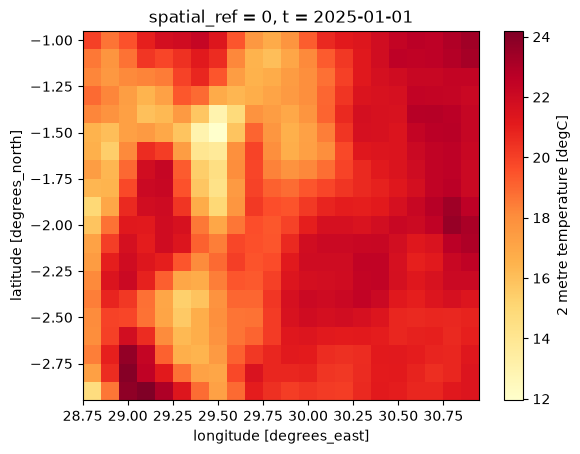

In [5]:
# open zarr archive as xarray
climate_ds = xr.open_zarr(
    climate_zarr_url,
    consolidated=True,
)

# visualize contents
climate_ds["t2m"].isel(t=0).plot(cmap="YlOrRd")

## Administrative Areas

Make sure you have imported the administrative areas that you want to use for aggregating and reporting climate statistics. These are the locations for which climate data is reported in your final Chap CSV file. 

You can use any polygon-based vector dataset, but an easy way to get started is using the builtin Overture Maps vector data source:

- Configure which boundaries you would like to import following [this guide](https://open-climate-service.dhis2.org/built_in_datasets/?h=overture#overture-maps-administrative-divisions-feature-collection).
- Trigger the import from the [Overture Maps data source page](http://localhost:9000/data-sources/overture_divisions). 

### To connect with openeo

In [ ]:
# the dataset id for imported boundaries
boundaries_dataset_id = "overture_divisions_adm3"
boundaries_features_url = f"{ocs_url}/features/{boundaries_dataset_id}/data.parquet"

# load openeo collection
boundaries = conn.load_collection(
    boundaries_dataset_id,
)
print(boundaries)

### To visualize the data

                                              geometry  \
0    POLYGON ((28.89336 -2.4907, 28.89333 -2.49079,...   
1    POLYGON ((28.92888 -2.49373, 28.92917 -2.49405...   
2    POLYGON ((28.92918 -2.49449, 28.92911 -2.4944,...   
3    POLYGON ((28.95439 -2.55921, 28.95489 -2.55978...   
4    POLYGON ((28.9013 -2.61689, 28.90086 -2.61828,...   
..                                                 ...   
427  POLYGON ((30.37234 -1.7655, 30.37075 -1.7637, ...   
428  POLYGON ((30.30442 -1.59241, 30.30215 -1.58919...   
429  POLYGON ((30.23197 -1.25152, 30.23186 -1.25175...   
430  POLYGON ((30.78244 -2.14565, 30.78307 -2.14571...   
431  POLYGON ((30.8487 -2.19978, 30.84909 -2.19945,...   

                                       id   subtype class        name country  \
0    b3752063-bf50-465a-a845-c39e983321fc  locality  land      Mururu      RW   
1    44e2947c-b472-4900-b370-684f693904e2  locality  land    Gihundwe      RW   
2    5cc1dcf3-cbda-439d-a9d3-5f65b859d282  locality  land   

<Axes: title={'center': 'spatial_ref = 0, t = 2025-01-01'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

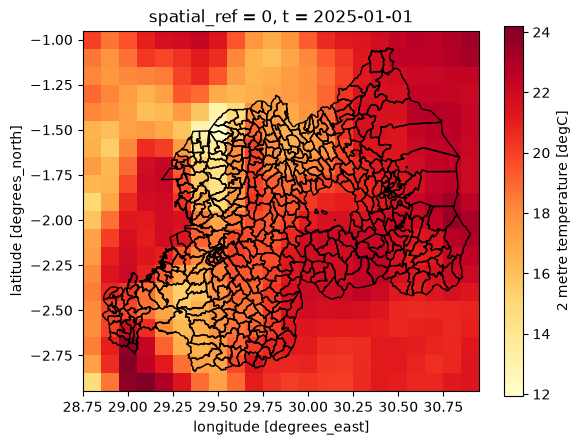

In [ ]:
# open the data as parquet
boundaries_df = gpd.read_parquet(boundaries_features_url)
print(boundaries_df)

# visualize together with climate
ax = plt.subplot(1, 1, 1)

# plot climate
climate_ds["t2m"].isel(t=0).plot(ax=ax, cmap="YlOrRd")

# add boundaries
boundaries_df.plot(ax=ax, color="none")

## Aggregate to administrative areas

### To run the aggregation and save as CSV

In [ ]:
# aggregate climate data by boundaries
agg = climate.process(
    "aggregate_spatial_weighted",
    data=climate,
    geometries=boundaries,
    reducer="mean",
)

# save to csv
csv_path = "outputs/aggregated.csv"
agg.download(csv_path, format="CSV")

NameError: name 'climate' is not defined

### To load and inspect the CSV

In [ ]:
# load the csv file to pandas
agg_df = pd.read_csv(csv_path)

# inspect the data
agg_df

,t,feature_id,t2m
0,2025-01-01,b3752063-bf50-465a-a845-c39e983321fc,19.941111
1,2025-01-01,44e2947c-b472-4900-b370-684f693904e2,20.311830
2,2025-01-01,5cc1dcf3-cbda-439d-a9d3-5f65b859d282,19.943756
3,2025-01-01,7e0d6c09-ab60-4673-a748-b8ad9a3e9884,20.035330
4,2025-01-01,592bc1fb-a96d-4598-943b-b5fee2004970,20.469115
...,...,...,...
51835,2025-04-30,c799ca1f-0230-43a5-83a3-0b2b9dc95bc6,19.909372
51836,2025-04-30,38252c6d-6225-4860-8102-5b7e038c28d6,20.248769
51837,2025-04-30,fba48afe-2985-4cf0-86d8-5da800142a6c,20.583186
51838,2025-04-30,8d5dd519-069e-42f0-8e75-2efd0d52e045,21.363013


### To visualize results along with geometries

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

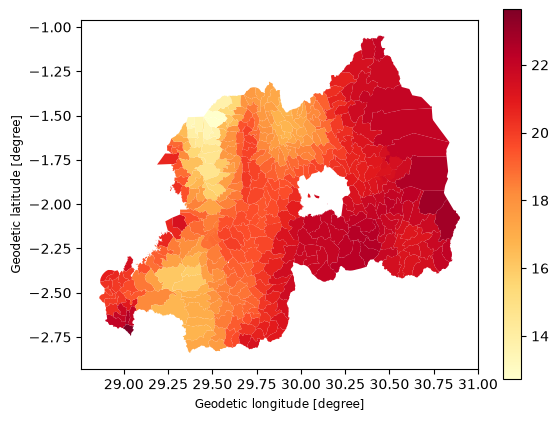

In [ ]:
agg_df_snapshot = agg_df[agg_df['t']=="2025-01-01"].rename(columns={"feature_id": "id"})
boundaries_with_climate = boundaries_df.merge(agg_df_snapshot, on='id', how='left')
boundaries_with_climate.plot(column="t2m", cmap="YlOrRd", legend=True)